# 03. Bbox Crop 및 저장

다운로드된 이미지에서 bbox 영역을 잘라내어 `data/processed/{class_name}/`에 저장합니다.

**전제조건**: `02_download_images.ipynb` 실행 완료

**bbox 좌표 형식** (Open Images 기준)
- XMin, XMax: 이미지 너비 대비 0~1 비율
- YMin, YMax: 이미지 높이 대비 0~1 비율
- 픽셀 변환: `x1 = XMin * width`

**필터 조건**
- crop 너비 또는 높이가 `config.MIN_CROP_SIZE`(64px) 미만이면 저장하지 않음

In [1]:
import os
import sys
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

manifest = pd.read_csv(config.MANIFEST_PATH)
print(f'처리 대상 bbox 수: {len(manifest)}')
print(manifest['ClassName'].value_counts())

처리 대상 bbox 수: 200
ClassName
Refrigerator       100
Washing machine    100
Name: count, dtype: int64


In [2]:
def crop_and_save(image_id, class_name, xmin, xmax, ymin, ymax, crop_idx):
    """
    raw 이미지에서 bbox를 잘라 processed/{class_name}/ 에 저장.
    반환값: ('ok'|'skip'|'fail', 설명)
    """
    raw_path = os.path.join(config.RAW_DIR, f'{image_id}.jpg')
    if not os.path.exists(raw_path):
        return 'skip', f'{image_id} 파일 없음'

    try:
        img = Image.open(raw_path).convert('RGB')
        w, h = img.size

        # 정규화 좌표 → 픽셀 좌표 변환 + 경계 클램핑
        x1 = max(0, int(xmin * w))
        y1 = max(0, int(ymin * h))
        x2 = min(w, int(xmax * w))
        y2 = min(h, int(ymax * h))

        crop_w = x2 - x1
        crop_h = y2 - y1

        if crop_w < config.MIN_CROP_SIZE or crop_h < config.MIN_CROP_SIZE:
            return 'skip', f'{image_id} crop 너무 작음 ({crop_w}x{crop_h})'

        crop = img.crop((x1, y1, x2, y2))

        # 폴더명: 공백→언더스코어, 소문자
        folder = class_name.replace(' ', '_').lower()
        out_dir = os.path.join(config.PROCESSED_DIR, folder)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, f'{image_id}_{crop_idx:02d}.jpg')
        crop.save(out_path, 'JPEG', quality=95)
        return 'ok', out_path

    except Exception as e:
        return 'fail', f'{image_id}: {e}'

In [3]:
results = {'ok': 0, 'skip': 0, 'fail': 0}
fail_log = []

# 같은 이미지에서 여러 bbox가 나올 때 파일명 충돌 방지용 카운터
crop_counter = {}

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Bbox crop'):
    iid = row['ImageID']
    crop_counter[iid] = crop_counter.get(iid, 0)

    status, detail = crop_and_save(
        image_id  = iid,
        class_name= row['ClassName'],
        xmin      = row['XMin'],
        xmax      = row['XMax'],
        ymin      = row['YMin'],
        ymax      = row['YMax'],
        crop_idx  = crop_counter[iid]
    )
    crop_counter[iid] += 1
    results[status] += 1
    if status == 'fail':
        fail_log.append(detail)

print(f'\n완료 — 저장: {results["ok"]}, 스킵: {results["skip"]}, 실패: {results["fail"]}')
if fail_log:
    print('\n실패 목록:')
    for msg in fail_log:
        print(f'  {msg}')

Bbox crop:   0%|          | 0/200 [00:00<?, ?it/s]


완료 — 저장: 168, 스킵: 32, 실패: 0


In [4]:
# 클래스별 저장된 crop 수 확인
print('=== data/processed/ 현황 ===')
for entry in sorted(os.scandir(config.PROCESSED_DIR), key=lambda e: e.name):
    if entry.is_dir():
        count = len([f for f in os.listdir(entry.path) if f.endswith('.jpg')])
        print(f'  {entry.name}: {count}개')

=== data/processed/ 현황 ===
  refrigerator: 85개
  washing_machine: 83개


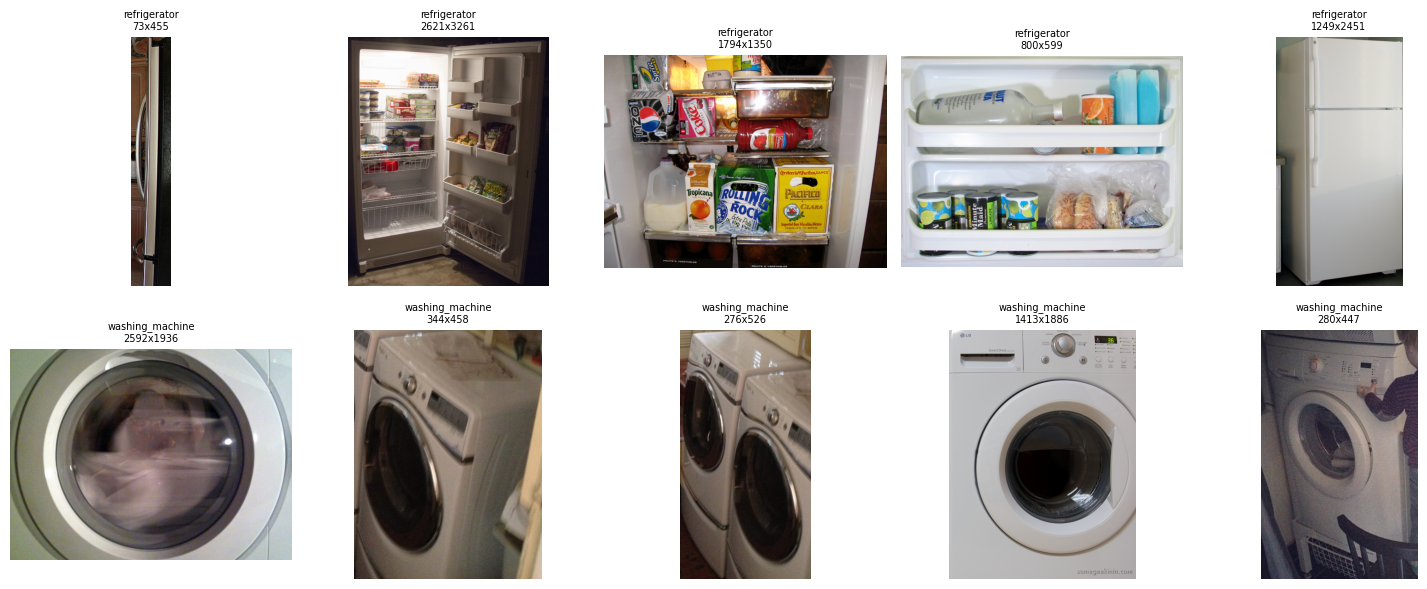

샘플 저장: data\metadata\sample_crops.png

데이터 수집 파이프라인 완료!
다음 단계: 05_train_efficientnetv2.ipynb (학습)


In [5]:
# 클래스별 샘플 crop 시각화 (클래스당 5장)
import matplotlib.pyplot as plt

class_dirs = sorted(
    [e for e in os.scandir(config.PROCESSED_DIR) if e.is_dir()],
    key=lambda e: e.name
)

samples_per_class = 5
n_classes = len(class_dirs)
fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(15, 3 * n_classes))

# n_classes==1 이면 axes가 1D → 2D로 맞춤
if n_classes == 1:
    axes = [axes]

for row_idx, entry in enumerate(class_dirs):
    files = sorted([f for f in os.listdir(entry.path) if f.endswith('.jpg')])[:samples_per_class]
    for col_idx in range(samples_per_class):
        ax = axes[row_idx][col_idx]
        if col_idx < len(files):
            img = Image.open(os.path.join(entry.path, files[col_idx]))
            ax.imshow(img)
            ax.set_title(f'{entry.name}\n{img.size[0]}x{img.size[1]}', fontsize=7)
        ax.axis('off')

plt.tight_layout()
out_png = os.path.join(config.METADATA_DIR, 'sample_crops.png')
plt.savefig(out_png, dpi=100, bbox_inches='tight')
plt.show()
print(f'샘플 저장: {out_png}')
print('\n데이터 수집 파이프라인 완료!')
print('다음 단계: 05_train_efficientnetv2.ipynb (학습)')